<a href="https://colab.research.google.com/github/achanltgd617-design/proteomics-plots/blob/main/SERS_LFA_simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 安裝中文字型 (只需跑一次, 之後重開筆記本要再跑)
!apt-get install -y fonts-noto-cjk > /dev/null 2>&1

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 載入剛裝好的 Noto Sans CJK 字型
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
font_manager.fontManager.addfont(font_path)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=font_path).get_name()
plt.rcParams["axes.unicode_minus"] = False   # 讓負號正常顯示

print("中文字型已設定完成,現在可以重新執行主程式了")


中文字型已設定完成,現在可以重新執行主程式了


In [3]:
# ============================================================
#  SERS-LFA 細菌偵測模擬器 (互動版)
#  使用方法: 直接執行這個 cell, 下方會出現滑桿與圖表
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

class SERS_LFA_Simulator:
    def __init__(self, channel="T1", seed=42):
        self.SERS_EF = 1.95e8
        self.t_assay = 20 * 60
        self.v_flow = 0.5
        self.T_line_width = 1.0
        self.tags_per_bacterium = 5e3
        self.hotspots_per_tag = 50
        self.signal_per_hotspot = 2e-8
        self.background = 10.0
        self.noise_floor = 2.0
        self.noise_rel = 0.02
        if channel == "T1":
            self.C_half = 3e3
            self.linear_range = (10, 1e3)
            self.hook_onset = 1e6
            self.hook_enabled = True
        elif channel == "T2":
            self.C_half = 8e3
            self.linear_range = (10, 5e3)
            self.hook_onset = np.inf
            self.hook_enabled = False
        self.channel = channel
        self.hill = 1.0
        self.rng = np.random.default_rng(seed)

    def _max_signal(self):
        tags_total = self.tags_per_bacterium * self.hotspots_per_tag
        ef_term = np.log10(self.SERS_EF)
        return tags_total * self.signal_per_hotspot * ef_term * 1e4

    def _four_pl(self, C):
        I_max = self._max_signal()
        C = np.maximum(C, 1e-9)
        return I_max / (1.0 + (self.C_half / C) ** self.hill)

    def _hook_factor(self, C):
        if not self.hook_enabled or not np.isfinite(self.hook_onset):
            return np.ones_like(np.asarray(C, dtype=float))
        C = np.asarray(C, dtype=float)
        return 1.0 / (1.0 + (C / self.hook_onset) ** 2)

    def _read_signal(self, C):
        ideal = self._four_pl(C) * self._hook_factor(C)
        sigma = self.noise_floor + self.noise_rel * ideal
        noise = self.rng.normal(0.0, sigma)
        return max(self.background, ideal + self.background + noise)

    def calibration_curve(self, C_range, replicates=1):
        concentrations = np.asarray(C_range, dtype=float)
        means, stds = [], []
        for C in concentrations:
            reads = np.array([self._read_signal(C) for _ in range(replicates)])
            means.append(reads.mean())
            stds.append(reads.std())
        return {"concentration": concentrations,
                "signal_mean": np.array(means),
                "signal_std": np.array(stds)}

    def estimate_LOD(self, n_blank=20):
        blanks = np.array([self._read_signal(0.0) for _ in range(n_blank)])
        threshold = blanks.mean() + 3 * blanks.std()
        grid = np.logspace(0, 7, 100000)
        ideal = self._four_pl(grid) * self._hook_factor(grid) + self.background
        above = np.where(ideal >= threshold)[0]
        return grid[above[0]] if len(above) else np.nan


# ---------- 互動介面 ----------
def interactive_sim(channel, tags_per_bacterium, hotspots_per_tag,
                    signal_per_hotspot_exp, noise_floor, replicates):
    sim = SERS_LFA_Simulator(channel=channel, seed=42)
    # 套用滑桿的數值
    sim.tags_per_bacterium = tags_per_bacterium
    sim.hotspots_per_tag = hotspots_per_tag
    sim.signal_per_hotspot = 10 ** signal_per_hotspot_exp
    sim.noise_floor = noise_floor

    C_range = np.logspace(0, 7, 25)
    data = sim.calibration_curve(C_range, replicates=replicates)
    lod = sim.estimate_LOD()

    plt.figure(figsize=(9, 5.5))
    plt.errorbar(data["concentration"], data["signal_mean"],
                 yerr=data["signal_std"], fmt="o-", capsize=3,
                 color="#1f77b4", label="模擬 SERS 訊號")
    lo, hi = sim.linear_range
    plt.axvspan(lo, hi, alpha=0.12, color="green",
                label=f"線性範圍 {lo:.0f}–{hi:.0f}")
    plt.axvline(lod, ls="--", color="red", label=f"LOD ≈ {lod:.0f} cells/mL")
    if sim.hook_enabled:
        plt.axvline(sim.hook_onset, ls=":", color="purple",
                    label=f"Hook onset {sim.hook_onset:.0e}")
    plt.xscale("log")
    plt.xlabel("細菌濃度 (cells/mL)")
    plt.ylabel("SERS 訊號強度 (a.u.)")
    plt.title(f"SERS-LFA 校準曲線  —  通道 {channel}")
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.show()
    print(f"目前估算 LOD ≈ {lod:.1f} cells/mL   (文獻參考值 ~9 cells/mL)")


widgets.interact(
    interactive_sim,
    channel=widgets.Dropdown(options=["T1", "T2"], value="T1",
                             description="通道"),
    tags_per_bacterium=widgets.FloatLogSlider(
        value=5e3, base=10, min=2, max=5, step=0.1,
        description="每菌tag數"),
    hotspots_per_tag=widgets.IntSlider(
        value=50, min=10, max=200, step=10,
        description="每tag熱點"),
    signal_per_hotspot_exp=widgets.FloatSlider(
        value=-8, min=-9, max=-6, step=0.1,
        description="熱點強度(10^x)"),
    noise_floor=widgets.FloatSlider(
        value=2.0, min=0.5, max=10, step=0.5,
        description="雜訊強度"),
    replicates=widgets.IntSlider(
        value=5, min=1, max=20, step=1,
        description="重複次數"),
);


interactive(children=(Dropdown(description='通道', options=('T1', 'T2'), value='T1'), FloatLogSlider(value=5000.…

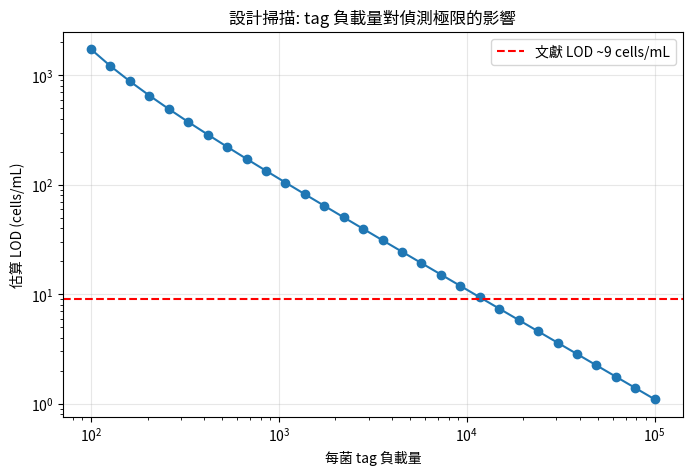

要達到 LOD≈9, 每菌 tag 數至少需要 ~14874


In [4]:
# 系統性掃描: tag 數 vs LOD (這是真正的 in silico 實驗, 會產生可存檔的數據)
import numpy as np
import matplotlib.pyplot as plt

tag_values = np.logspace(2, 5, 30)   # 從 100 到 100000, 掃 30 個點
lods = []
for tags in tag_values:
    sim = SERS_LFA_Simulator(channel="T1")
    sim.tags_per_bacterium = tags
    lods.append(sim.estimate_LOD())

plt.figure(figsize=(8, 5))
plt.plot(tag_values, lods, "o-")
plt.xscale("log"); plt.yscale("log")
plt.axhline(9, ls="--", color="red", label="文獻 LOD ~9 cells/mL")
plt.xlabel("每菌 tag 負載量"); plt.ylabel("估算 LOD (cells/mL)")
plt.title("設計掃描: tag 負載量對偵測極限的影響")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 找出達到文獻 LOD 需要的最小 tag 數
idx = np.where(np.array(lods) <= 9)[0]
if len(idx):
    print(f"要達到 LOD≈9, 每菌 tag 數至少需要 ~{tag_values[idx[0]]:.0f}")


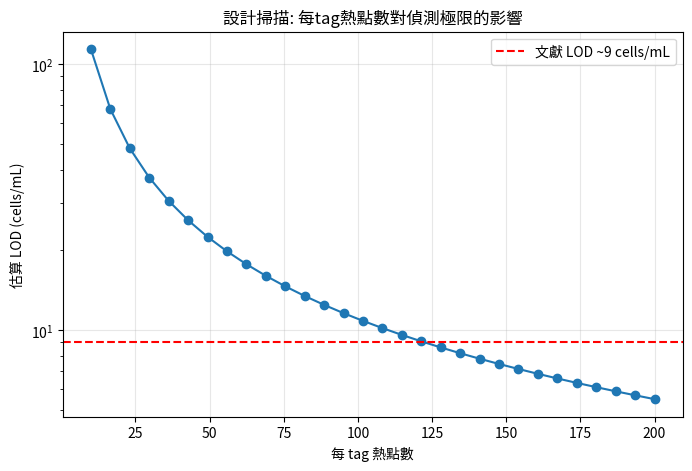

要達到 LOD≈9, 每 tag 熱點數至少需要 ~128


In [5]:
# 系統性掃描: 每tag熱點 vs LOD
import numpy as np
import matplotlib.pyplot as plt

hotspot_values = np.linspace(10, 200, 30)   # 從 10 到 200, 掃 30 個點
lods = []
for hs in hotspot_values:
    sim = SERS_LFA_Simulator(channel="T1")
    sim.hotspots_per_tag = hs            # <-- 改成控制「每tag熱點」
    lods.append(sim.estimate_LOD())

plt.figure(figsize=(8, 5))
plt.plot(hotspot_values, lods, "o-")
plt.yscale("log")                        # 縱軸維持對數 (LOD 範圍大)
plt.axhline(9, ls="--", color="red", label="文獻 LOD ~9 cells/mL")
plt.xlabel("每 tag 熱點數")
plt.ylabel("估算 LOD (cells/mL)")
plt.title("設計掃描: 每tag熱點數對偵測極限的影響")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

# 找出達到文獻 LOD 需要的最小熱點數
idx = np.where(np.array(lods) <= 9)[0]
if len(idx):
    print(f"要達到 LOD≈9, 每 tag 熱點數至少需要 ~{hotspot_values[idx[0]]:.0f}")
else:
    print("在 10–200 的範圍內都還達不到 LOD≈9, 可以試著調高其他參數")


In [6]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime

DB = "sers_lfa.db"   # 資料庫檔, 會存在 Colab 暫存空間

def init_db():
    """建立資料庫表格 (只需第一次跑)"""
    con = sqlite3.connect(DB)
    con.execute("""
        CREATE TABLE IF NOT EXISTS experiments (
            exp_id INTEGER PRIMARY KEY AUTOINCREMENT,
            time TEXT, channel TEXT,
            tags_per_bacterium REAL, hotspots_per_tag REAL,
            signal_per_hotspot REAL, noise_floor REAL,
            lod REAL
        )""")
    con.commit(); con.close()
    print("資料庫已就緒")

def save_experiment(sim):
    """把一個模擬器的設定與算出的 LOD 存進資料庫, 回傳這次的實驗編號"""
    lod = sim.estimate_LOD()
    con = sqlite3.connect(DB)
    cur = con.execute("""
        INSERT INTO experiments
        (time, channel, tags_per_bacterium, hotspots_per_tag,
         signal_per_hotspot, noise_floor, lod)
        VALUES (?,?,?,?,?,?,?)""",
        (datetime.now().strftime("%Y-%m-%d %H:%M:%S"), sim.channel,
         sim.tags_per_bacterium, sim.hotspots_per_tag,
         sim.signal_per_hotspot, sim.noise_floor, lod))
    con.commit(); exp_id = cur.lastrowid; con.close()
    print(f"已儲存實驗 #{exp_id}  (LOD≈{lod:.1f})")
    return exp_id

def load_all():
    """讀出所有歷史實驗, 變成一張表格"""
    con = sqlite3.connect(DB)
    df = pd.read_sql("SELECT * FROM experiments", con)
    con.close()
    return df

def export_csv(name="experiments.csv"):
    """把所有實驗匯出成 CSV 檔 (可下載)"""
    load_all().to_csv(name, index=False)
    print(f"已匯出 {name}")

init_db()


資料庫已就緒


In [7]:
# 示範: 跑三組不同參數, 各自存進資料庫
for tags in [1e3, 5e3, 1e4]:
    sim = SERS_LFA_Simulator(channel="T1")
    sim.tags_per_bacterium = tags
    save_experiment(sim)

load_all()   # 顯示目前所有實驗的表格


已儲存實驗 #1  (LOD≈113.9)
已儲存實驗 #2  (LOD≈22.1)
已儲存實驗 #3  (LOD≈11.0)


,exp_id,time,channel,tags_per_bacterium,hotspots_per_tag,signal_per_hotspot,noise_floor,lod
0,1,2026-06-15 06:24:31,T1,1000.0,50.0,2.000000e-08,2.0,113.851974
1,2,2026-06-15 06:24:31,T1,5000.0,50.0,2.000000e-08,2.0,22.098533
2,3,2026-06-15 06:24:31,T1,10000.0,50.0,2.000000e-08,2.0,11.009065


/tmp/ipykernel_1373/2980491970.py:5: RuntimeWarning: invalid value encountered in power
  return I_min + (I_max - I_min) / (1 + (C_half / C) ** hill)


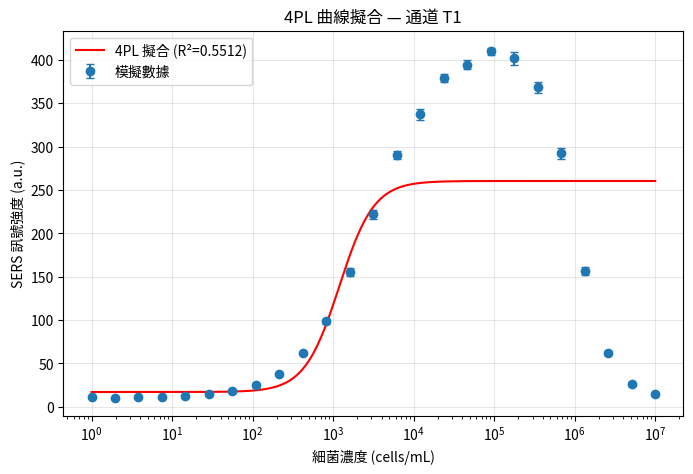

擬合參數: 半飽和濃度 C_half≈1192,  Hill斜率≈2.01
擬合優度 R² = 0.5512  (越接近1越好, 文獻為0.99以上)


(array([  17.09163652,  260.47539847, 1192.16198895,    2.01433178]),
 np.float64(0.5511793504381064))

In [8]:
from scipy.optimize import curve_fit

def four_pl_func(C, I_min, I_max, C_half, hill):
    """4 參數 S 形函數"""
    return I_min + (I_max - I_min) / (1 + (C_half / C) ** hill)

def fit_calibration(sim, replicates=5):
    """對模擬出的校準數據做 4PL 擬合, 畫圖並回報 R²"""
    C = np.logspace(0, 7, 25)
    data = sim.calibration_curve(C, replicates=replicates)
    y = data["signal_mean"]

    # 擬合 (給初始猜測值幫助收斂)
    p0 = [y.min(), y.max(), sim.C_half, 1.0]
    popt, _ = curve_fit(four_pl_func, C, y, p0=p0, maxfev=10000)

    # 算 R²
    y_pred = four_pl_func(C, *popt)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    # 畫圖: 數據點 + 擬合線
    plt.figure(figsize=(8, 5))
    plt.errorbar(C, y, yerr=data["signal_std"], fmt="o",
                 capsize=3, label="模擬數據")
    C_smooth = np.logspace(0, 7, 500)
    plt.plot(C_smooth, four_pl_func(C_smooth, *popt),
             "-", color="red", label=f"4PL 擬合 (R²={r2:.4f})")
    plt.xscale("log")
    plt.xlabel("細菌濃度 (cells/mL)")
    plt.ylabel("SERS 訊號強度 (a.u.)")
    plt.title(f"4PL 曲線擬合 — 通道 {sim.channel}")
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()
    print(f"擬合參數: 半飽和濃度 C_half≈{popt[2]:.0f},  Hill斜率≈{popt[3]:.2f}")
    print(f"擬合優度 R² = {r2:.4f}  (越接近1越好, 文獻為0.99以上)")
    return popt, r2

# 用法
sim = SERS_LFA_Simulator(channel="T1")
fit_calibration(sim)


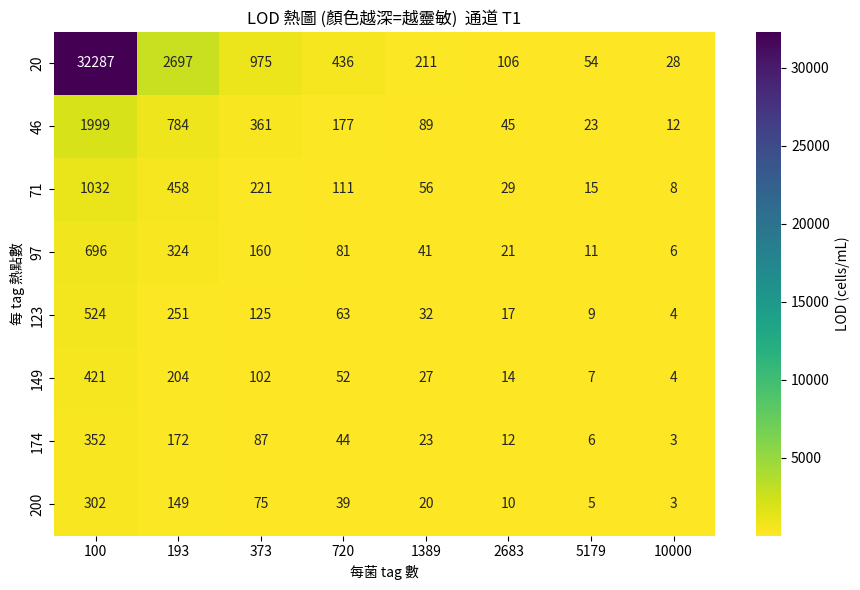

In [9]:
import seaborn as sns

def lod_heatmap(channel="T1", n=8):
    """掃描 [每菌tag數] × [每tag熱點] 的所有組合, 畫 LOD 熱圖"""
    tag_vals = np.logspace(2, 4, n)        # 100~10000
    hs_vals  = np.linspace(20, 200, n)     # 20~200

    grid = np.zeros((n, n))
    for i, hs in enumerate(hs_vals):
        for j, tg in enumerate(tag_vals):
            sim = SERS_LFA_Simulator(channel=channel)
            sim.tags_per_bacterium = tg
            sim.hotspots_per_tag = hs
            grid[i, j] = sim.estimate_LOD()

    df = pd.DataFrame(grid,
                      index=[f"{v:.0f}" for v in hs_vals],
                      columns=[f"{v:.0f}" for v in tag_vals])
    plt.figure(figsize=(9, 6))
    sns.heatmap(df, annot=True, fmt=".0f", cmap="viridis_r",
                cbar_kws={"label": "LOD (cells/mL)"})
    plt.xlabel("每菌 tag 數")
    plt.ylabel("每 tag 熱點數")
    plt.title(f"LOD 熱圖 (顏色越深=越靈敏)  通道 {channel}")
    plt.tight_layout(); plt.show()

lod_heatmap("T1")


In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

def run_anova(channel="T1", replicates=3):
    """
    對三個參數做因子實驗 + ANOVA, 判斷哪個對 LOD 影響顯著。
    每個參數取 低/高 兩個水平, 全組合各重複幾次。
    """
    # 三個參數各取 低/高 兩個水平
    levels = {
        "tags":     [1e3, 1e4],     # 每菌 tag 數
        "hotspots": [20, 200],      # 每 tag 熱點數
        "noise":    [1.0, 8.0],     # 雜訊強度
    }

    rows = []
    for tg in levels["tags"]:
        for hs in levels["hotspots"]:
            for ns in levels["noise"]:
                for rep in range(replicates):
                    sim = SERS_LFA_Simulator(channel=channel,
                                             seed=rep)  # 不同種子=不同重複
                    sim.tags_per_bacterium = tg
                    sim.hotspots_per_tag = hs
                    sim.noise_floor = ns
                    rows.append({
                        "tags": tg, "hotspots": hs,
                        "noise": ns, "lod": sim.estimate_LOD()
                    })

    df = pd.DataFrame(rows)
    print(f"共跑了 {len(df)} 次模擬實驗\n")

    # 建立統計模型: LOD 受三個因子影響
    model = ols("lod ~ C(tags) + C(hotspots) + C(noise)", data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    # 整理成好讀的結果
    print("===== ANOVA 變異數分析結果 =====")
    result = anova_table[["F", "PR(>F)"]].copy()
    result.columns = ["F值(影響力)", "p值(顯著性)"]
    result["結論"] = result["p值(顯著性)"].apply(
        lambda p: "✅ 顯著影響 (值得調)" if p < 0.05
        else "⚪ 影響不明顯")
    # 把因子名稱換成中文
    name_map = {"C(tags)": "每菌tag數", "C(hotspots)": "每tag熱點",
                "C(noise)": "雜訊強度", "Residual": "（殘差/誤差）"}
    result.index = [name_map.get(i, i) for i in result.index]
    print(result.to_string())
    print("\n說明: p值 < 0.05 = 這個參數確實顯著影響 LOD;")
    print("      F值越大 = 這個參數的影響力越強。")
    return df, result

# 用法
df, result = run_anova("T1")


共跑了 24 次模擬實驗

===== ANOVA 變異數分析結果 =====
          F值(影響力)   p值(顯著性)            結論
每菌tag數   6.095446  0.022688  ✅ 顯著影響 (值得調)
每tag熱點   6.095446  0.022688  ✅ 顯著影響 (值得調)
雜訊強度     5.677806  0.027215  ✅ 顯著影響 (值得調)
（殘差/誤差）       NaN       NaN       ⚪ 影響不明顯

說明: p值 < 0.05 = 這個參數確實顯著影響 LOD;
      F值越大 = 這個參數的影響力越強。
